**# Neural Network from Scratch -- Superconductivity Prediction**

**## Problem Definition**

This project implements a neural network from scratch to predict the critical temperature (Tc) of superconductors.

**## Goal**

- Train a neural network using gradient descent and backpropagation
- Minimise Mean Squared Error (MSE) loss
- Demonstrate improvement of the loss during training

**## Dataset**

- Superconductivity dataset
- 21263 samples
- 81 numerical input features
- Target variable: `critical_temp`

In [ ]:
# Neural Network from Scratch -- Superconductivity Prediction
# Assignment 2 - Mathematics for Analytics
# Author: Sedat Aydin
# Import required libraries
# NumPy for numerical operations
# Matplotlib for plotting
# Pandas for reading the dataset

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
# Create a dataframe from the uploaded CSV file
# We read the dataset and check its shape
# This confirms that the data was loaded correctly

DATA_PATH = "superconductivity.data.csv"
df = pd.read_csv(DATA_PATH)

print(df.shape)

(21263, 82)


In [ ]:
# Split dataset into features (X) and target (y)
# X = all columns except the last one
# y = last column (critical temperature)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Check the shapes
X.shape, y.shape

((21263, 81), (21263,))

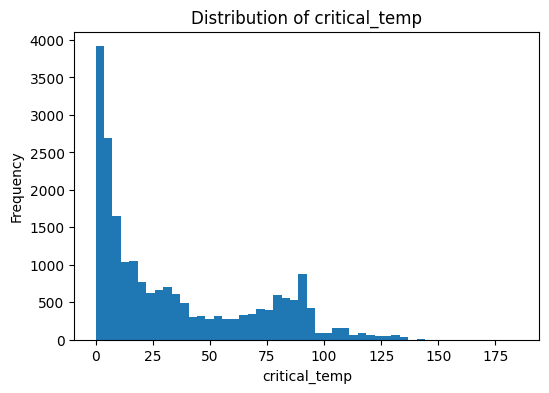

Min: 0.00021
Mean: 34.42121913535249
Max: 185.0


In [ ]:
# Plot distribution of target variable (critical_temp)

# Create figure
plt.figure(figsize=(6,4))

# Plot histogram
plt.hist(y, bins=50)

# Add labels and title
plt.title("Distribution of critical_temp")
plt.xlabel("critical_temp")
plt.ylabel("Frequency")


# Show plot
plt.show()

# Print basic statistics
print("Min:", y.min())
print("Mean:", y.mean())
print("Max:", y.max())

In [ ]:
# Split data into train and test sets manually
# 80% for training, 20% for testing

# Reproducibility: fix randomness so results are repeatable
np.random.seed(42)

# Shuffle the data indices
indices = np.arange(X.shape[0])
np.random.shuffle(indices)


# Apply shuffle
X = X[indices]
y = y[indices]

# Define split point
split_index = int(0.8 * len(X))

# Split data
X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

# Check shapes
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((17010, 81), (4253, 81), (17010,), (4253,))

In [ ]:
# Standardise features using training data statistics only
# This is crucial for stable and faster gradient descent in high-dimensional problems
# We compute mean/std from X_train, then apply the same transformation to both X_train and X_test

# Compute feature-wise mean and standard deviation from the training set
X_train_mean = X_train.mean(axis=0)
X_train_std = X_train.std(axis=0)

# Avoid division by zero (in case a feature has zero variance)
X_train_std = np.where(X_train_std < 1e-12, 1.0, X_train_std)

# Apply standardisation
X_train_scaled = (X_train - X_train_mean) / X_train_std
X_test_scaled  = (X_test  - X_train_mean) / X_train_std

# Quick sanity checks
X_train_scaled.shape, X_test_scaled.shape

((17010, 81), (4253, 81))

**## Attempt 1 -- Baseline Neural Network**

- Architecture: 81 → 8 → 1
- Activation: ReLU (hidden), Linear (output)
- Learning rate: 0.01
- Setup: initial baseline configuration
- Expected: establish baseline performance

In [ ]:
# Define regression metrics
# MSE measures average squared error
# R² measures how much variance is explained by the model (1 is best)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1.0 - (ss_res / ss_tot)

In [ ]:
# Initialise a simple 1-hidden-layer neural network for regression
# Architecture: 81 -> 8 -> 1
# Hidden activation: ReLU
# Output activation: Linear

input_dim = X_train_scaled.shape[1]
hidden_dim = 8
output_dim = 1

# He initialisation is a good default for ReLU networks
W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
b1 = np.zeros((1, hidden_dim))

W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2.0 / hidden_dim)
b2 = np.zeros((1, output_dim))

In [ ]:
# Define ReLU activation and its derivative for backpropagation

def relu(z):
    return np.maximum(0.0, z)

def relu_prime(z):
    return (z > 0.0).astype(float)

In [ ]:
## Attempt 1 -- Baseline Neural Network
#Architecture: 81 → 8 → 1
#Activation: ReLU (hidden), Linear (output)
#Learning rate: 0.01
#Setup: initial baseline configuration
#Expected: establish baseline performance
# Train the network using batch gradient descent
# We store learning curves (MSE and R²) to plot later

learning_rate = 0.01
epochs = 800
print_every = 100

# Ensure y is 2D for matrix math
y_train_2d = y_train.reshape(-1, 1)
y_test_2d = y_test.reshape(-1, 1)

train_mse_history = []
test_mse_history = []
train_r2_history = []
test_r2_history = []

for epoch in range(1, epochs + 1):

    # ----- Forward pass -----
    z1 = X_train_scaled @ W1 + b1
    a1 = relu(z1)
    y_hat = a1 @ W2 + b2  # linear output

    # ----- Compute loss gradient (MSE) -----
    n = X_train_scaled.shape[0]
    dY = (2.0 / n) * (y_hat - y_train_2d)   # dL/dy_hat

    # ----- Backpropagation -----
    dW2 = a1.T @ dY
    db2 = np.sum(dY, axis=0, keepdims=True)

    dA1 = dY @ W2.T
    dZ1 = dA1 * relu_prime(z1)

    dW1 = X_train_scaled.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # ----- Gradient descent update -----
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    # ----- Track metrics (train + test) -----
    train_mse_val = mse(y_train_2d, y_hat)
    train_r2_val = r2_score(y_train_2d, y_hat)

    # Test forward pass
    z1_test = X_test_scaled @ W1 + b1
    a1_test = relu(z1_test)
    y_hat_test = a1_test @ W2 + b2

    test_mse_val = mse(y_test_2d, y_hat_test)
    test_r2_val = r2_score(y_test_2d, y_hat_test)

    train_mse_history.append(train_mse_val)
    test_mse_history.append(test_mse_val)
    train_r2_history.append(train_r2_val)
    test_r2_history.append(test_r2_val)

    # Print progress across epochs (evidence of learning)
    if epoch == 1 or epoch % print_every == 0 or epoch == epochs:
        print(
            f"Epoch {epoch:4d} | "
            f"Train MSE {train_mse_val:10.4f} | Test MSE {test_mse_val:10.4f} | "
            f"Train R2 {train_r2_val:7.4f} | Test R2 {test_r2_val:7.4f}"
        )

Epoch    1 | Train MSE  2399.3873 | Test MSE  2342.5777 | Train R2 -1.0528 | Test R2 -0.9667


/tmp/ipython-input-2969106029.py:6: RuntimeWarning: overflow encountered in square
  return np.mean((y_true - y_pred) ** 2)
/tmp/ipython-input-2969106029.py:9: RuntimeWarning: overflow encountered in square
  ss_res = np.sum((y_true - y_pred) ** 2)
/tmp/ipython-input-21609063.py:57: RuntimeWarning: overflow encountered in matmul
  y_hat_test = a1_test @ W2 + b2
/tmp/ipython-input-21609063.py:28: RuntimeWarning: overflow encountered in matmul
  y_hat = a1 @ W2 + b2  # linear output
/tmp/ipython-input-21609063.py:38: RuntimeWarning: overflow encountered in matmul
  dA1 = dY @ W2.T
/tmp/ipython-input-21609063.py:39: RuntimeWarning: invalid value encountered in multiply
  dZ1 = dA1 * relu_prime(z1)
/tmp/ipython-input-21609063.py:41: RuntimeWarning: invalid value encountered in matmul
  dW1 = X_train_scaled.T @ dZ1


Epoch  100 | Train MSE        nan | Test MSE        nan | Train R2     nan | Test R2     nan
Epoch  200 | Train MSE        nan | Test MSE        nan | Train R2     nan | Test R2     nan
Epoch  300 | Train MSE        nan | Test MSE        nan | Train R2     nan | Test R2     nan
Epoch  400 | Train MSE        nan | Test MSE        nan | Train R2     nan | Test R2     nan
Epoch  500 | Train MSE        nan | Test MSE        nan | Train R2     nan | Test R2     nan
Epoch  600 | Train MSE        nan | Test MSE        nan | Train R2     nan | Test R2     nan
Epoch  700 | Train MSE        nan | Test MSE        nan | Train R2     nan | Test R2     nan
Epoch  800 | Train MSE        nan | Test MSE        nan | Train R2     nan | Test R2     nan


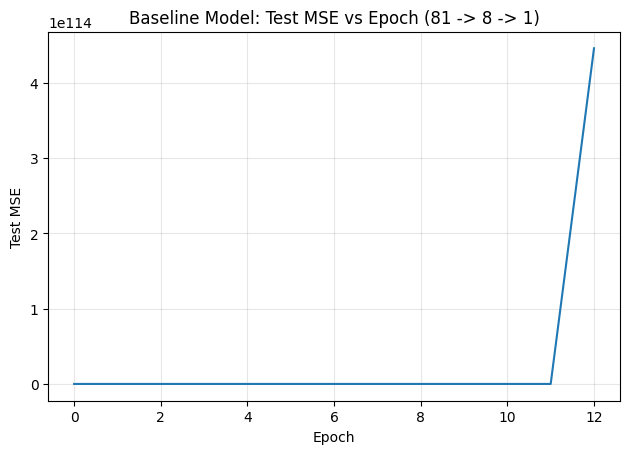

In [ ]:
# Plot the learning curve (Test MSE vs Epoch)
# This is a key piece of evidence for training behaviour

plt.figure()
plt.plot(test_mse_history)
plt.xlabel("Epoch")
plt.ylabel("Test MSE")
plt.title("Baseline Model: Test MSE vs Epoch (81 -> 8 -> 1)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**### Attempt 1 — Results Interpretation**

Observations:

- Training diverged due to high learning rate (0.01).
- MSE increased rapidly and produced unstable values.
- R² stayed negative, indicating failure to learn.

Conclusion:
The learning rate was too aggressive, causing optimisation instability.


**## Attempt 2 -- Smaller Learning Rate**

- Architecture: 81 → 8 → 1
- Activation: ReLU (hidden), Linear (output)
- Learning rate: 0.001
- Change from Attempt 1: reduced learning rate
- Expected: stable training and smooth convergence

In [ ]:
## Attempt 2 -- Smaller Learning Rate
# Same architecture as Attempt 1 (81 -> 8 -> 1)
#Activation: ReLU (hidden), Linear (output)
#Learning rate: 0.001 Only change smaller learning rate to avoid divergence
#Change from Attempt 1: reduced learning rate
#Expected: stable training and smooth convergence

np.random.seed(42)

# Re-initialise weights (important!)
input_dim = X_train_scaled.shape[1]
hidden_dim = 8
output_dim = 1

W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
b1 = np.zeros((1, hidden_dim))

W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2.0 / hidden_dim)
b2 = np.zeros((1, output_dim))

# Training settings
learning_rate = 0.001   # reduced from 0.01
epochs = 800
print_every = 100

# Prepare targets
y_train_2d = y_train.reshape(-1, 1)
y_test_2d = y_test.reshape(-1, 1)

# History for plots
train_mse_history = []
test_mse_history = []
train_r2_history = []
test_r2_history = []

for epoch in range(1, epochs + 1):

    # ----- Forward pass -----
    z1 = X_train_scaled @ W1 + b1
    a1 = relu(z1)
    y_hat = a1 @ W2 + b2

    # ----- Loss gradient -----
    n = X_train_scaled.shape[0]
    dY = (2.0 / n) * (y_hat - y_train_2d)

    # ----- Backprop -----
    dW2 = a1.T @ dY
    db2 = np.sum(dY, axis=0, keepdims=True)

    dA1 = dY @ W2.T
    dZ1 = dA1 * relu_prime(z1)

    dW1 = X_train_scaled.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # ----- Gradient descent -----
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    # ----- Metrics -----
    train_mse_val = mse(y_train_2d, y_hat)
    train_r2_val = r2_score(y_train_2d, y_hat)

    z1_test = X_test_scaled @ W1 + b1
    a1_test = relu(z1_test)
    y_hat_test = a1_test @ W2 + b2

    test_mse_val = mse(y_test_2d, y_hat_test)
    test_r2_val = r2_score(y_test_2d, y_hat_test)

    train_mse_history.append(train_mse_val)
    test_mse_history.append(test_mse_val)
    train_r2_history.append(train_r2_val)
    test_r2_history.append(test_r2_val)

    if epoch == 1 or epoch % print_every == 0 or epoch == epochs:
        print(
            f"Epoch {epoch:4d} | "
            f"Train MSE {train_mse_val:10.4f} | Test MSE {test_mse_val:10.4f} | "
            f"Train R2 {train_r2_val:7.4f} | Test R2 {test_r2_val:7.4f}"
        )

Epoch    1 | Train MSE  2197.5855 | Test MSE  2018.3042 | Train R2 -0.8801 | Test R2 -0.6944
Epoch  100 | Train MSE   333.3682 | Test MSE   336.9664 | Train R2  0.7148 | Test R2  0.7171
Epoch  200 | Train MSE   298.2370 | Test MSE   298.7772 | Train R2  0.7448 | Test R2  0.7492
Epoch  300 | Train MSE   280.9528 | Test MSE   281.3735 | Train R2  0.7596 | Test R2  0.7638
Epoch  400 | Train MSE   269.1465 | Test MSE   269.7891 | Train R2  0.7697 | Test R2  0.7735
Epoch  500 | Train MSE   260.3663 | Test MSE   260.7748 | Train R2  0.7772 | Test R2  0.7811
Epoch  600 | Train MSE   253.6662 | Test MSE   253.9365 | Train R2  0.7830 | Test R2  0.7868
Epoch  700 | Train MSE   248.3163 | Test MSE   248.6363 | Train R2  0.7876 | Test R2  0.7913
Epoch  800 | Train MSE   244.2930 | Test MSE   244.7324 | Train R2  0.7910 | Test R2  0.7945


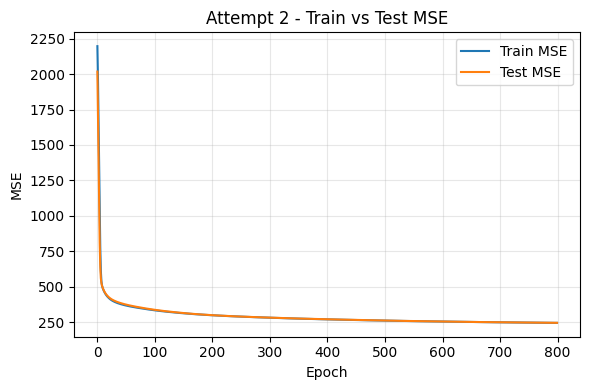

In [ ]:
# Plot training vs test loss (Attempt 2)
# Compare learning and generalisation behaviour

plt.figure(figsize=(6,4))

plt.plot(train_mse_history, label="Train MSE")
plt.plot(test_mse_history, label="Test MSE")

plt.title("Attempt 2 - Train vs Test MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

final_test_mse_2 = test_mse_history[-1]
best_test_mse_2 = min(test_mse_history)

final_test_r2_2 = test_r2_history[-1]
best_test_r2_2 = max(test_r2_history)

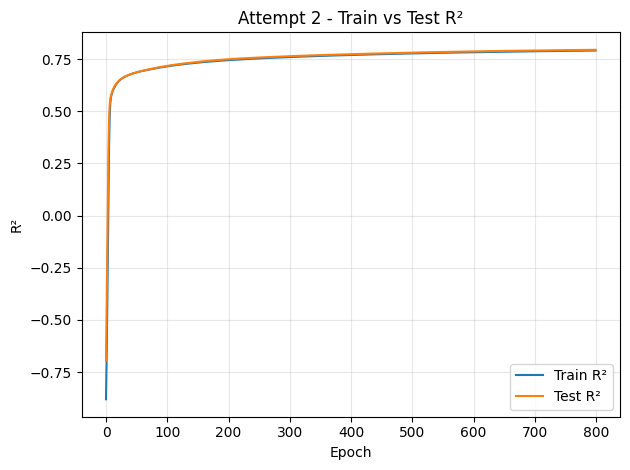

In [ ]:
# Plot R² learning curve for Attempt 2

plt.figure()

plt.plot(train_r2_history, label="Train R²")
plt.plot(test_r2_history, label="Test R²")

plt.title("Attempt 2 - Train vs Test R²")
plt.xlabel("Epoch")
plt.ylabel("R²")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**### Attempt 2 -- Results Interpretation**

Observations:
- Training remained stable
- Test MSE decreased rapidly in early epochs then flattened (convergence)
- Test R² improved to ~0.78 and stabilised after early epochs.
  Train and Test R² curves remained closely aligned, indicating good generalisation and stable learning behaviour.

Conclusion:
Reducing the learning rate fixed instability and enabled effective learning.

**## Attempt 3 -- Larger Hidden Layer**

- Architecture: 81 → 16 → 1
- Activation: ReLU (hidden), Linear (output)
- Learning rate: 0.001
- Change from Attempt 2: increased hidden neurons (8 → 16)
- Expected: lower test loss due to higher model capacity

In [ ]:
## Attempt 3 -- Larger Hidden Layer
#Architecture: 81 → 16 → 1
#Activation: ReLU (hidden), Linear (output)
#Learning rate: 0.001
#Change from Attempt 2: increased hidden neurons (8 → 16)
#Expected: lower test loss due to higher model capacity

np.random.seed(42)

# Re-initialise weights
input_dim = X_train_scaled.shape[1]
hidden_dim = 16
output_dim = 1

W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
b1 = np.zeros((1, hidden_dim))

W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2.0 / hidden_dim)
b2 = np.zeros((1, output_dim))

learning_rate = 0.001
epochs = 800
print_every = 100

y_train_2d = y_train.reshape(-1,1)
y_test_2d = y_test.reshape(-1,1)

train_mse_history_3 = []
test_mse_history_3 = []
train_r2_history_3 = []
test_r2_history_3 = []

for epoch in range(1, epochs+1):

    # Forward
    z1 = X_train_scaled @ W1 + b1
    a1 = relu(z1)
    y_hat = a1 @ W2 + b2

    # Loss gradient
    n = X_train_scaled.shape[0]
    dY = (2.0/n) * (y_hat - y_train_2d)

    # Backprop
    dW2 = a1.T @ dY
    db2 = np.sum(dY, axis=0, keepdims=True)

    dA1 = dY @ W2.T
    dZ1 = dA1 * relu_prime(z1)

    dW1 = X_train_scaled.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # Update
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    # Metrics
    train_mse_val = mse(y_train_2d, y_hat)
    train_r2_val = r2_score(y_train_2d, y_hat)

    z1_test = X_test_scaled @ W1 + b1
    a1_test = relu(z1_test)
    y_hat_test = a1_test @ W2 + b2

    test_mse_val = mse(y_test_2d, y_hat_test)
    test_r2_val = r2_score(y_test_2d, y_hat_test)

    train_mse_history_3.append(train_mse_val)
    test_mse_history_3.append(test_mse_val)
    train_r2_history_3.append(train_r2_val)
    test_r2_history_3.append(test_r2_val)

    if epoch == 1 or epoch % print_every == 0 or epoch == epochs:
        print(
            f"Epoch {epoch:4d} | "
            f"Train MSE {train_mse_val:10.4f} | Test MSE {test_mse_val:10.4f} | "
            f"Train R2 {train_r2_val:7.4f} | Test R2 {test_r2_val:7.4f}"
        )

Epoch    1 | Train MSE  2292.1641 | Test MSE  2249.8756 | Train R2 -0.9611 | Test R2 -0.8889
Epoch  100 | Train MSE   316.0418 | Test MSE   318.5272 | Train R2  0.7296 | Test R2  0.7326
Epoch  200 | Train MSE   289.8344 | Test MSE   291.2133 | Train R2  0.7520 | Test R2  0.7555
Epoch  300 | Train MSE   274.7781 | Test MSE   275.9444 | Train R2  0.7649 | Test R2  0.7683
Epoch  400 | Train MSE   264.1937 | Test MSE   265.2354 | Train R2  0.7740 | Test R2  0.7773
Epoch  500 | Train MSE   256.4029 | Test MSE   257.5488 | Train R2  0.7806 | Test R2  0.7838
Epoch  600 | Train MSE   250.3683 | Test MSE   251.6325 | Train R2  0.7858 | Test R2  0.7887
Epoch  700 | Train MSE   245.3894 | Test MSE   246.7968 | Train R2  0.7901 | Test R2  0.7928
Epoch  800 | Train MSE   240.9743 | Test MSE   242.4703 | Train R2  0.7938 | Test R2  0.7964


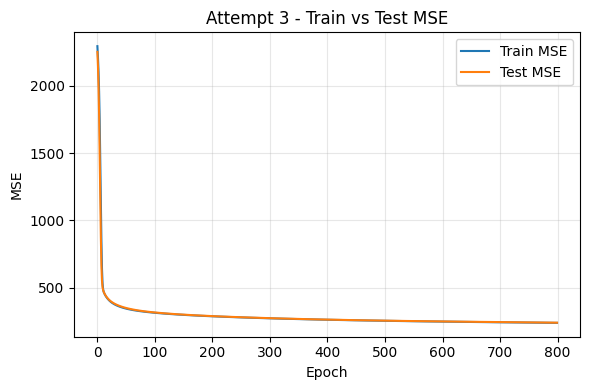

In [ ]:
# Plot training vs test loss (Attempt 3)

plt.figure(figsize=(6,4))

plt.plot(train_mse_history_3, label="Train MSE")
plt.plot(test_mse_history_3, label="Test MSE")

plt.title("Attempt 3 - Train vs Test MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

final_test_mse_3 = test_mse_history_3[-1]
best_test_mse_3  = min(test_mse_history_3)

final_test_r2_3  = test_r2_history_3[-1]
best_test_r2_3   = max(test_r2_history_3)



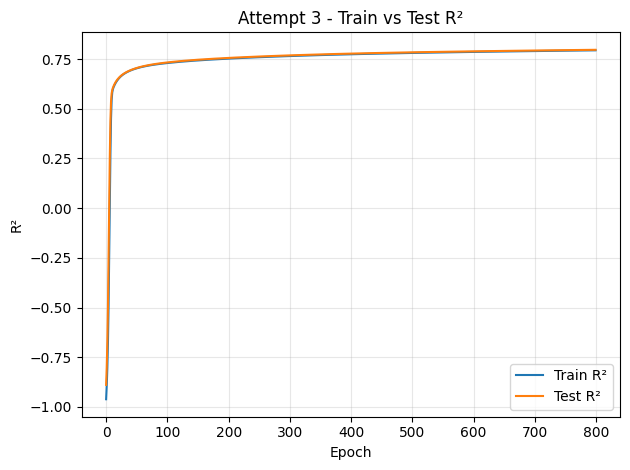

In [ ]:
# Plot R² learning curve for Attempt 3

plt.figure()

plt.plot(train_r2_history_3, label="Train R²")
plt.plot(test_r2_history_3, label="Test R²")

plt.title("Attempt 3 - Train vs Test R²")
plt.xlabel("Epoch")
plt.ylabel("R²")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


**### Attempt 3 -- Results Interpretation**

Observations:
- Training remained stable
- Test MSE decreased compared to Attempt 2
- Test R² improved slightly (~0.79). The R² curve reached a slightly higher plateau compared to Attempt 2, indicating improved model capacity.
The close alignment between train and test curves suggests minimal overfitting
and better generalisation performance.

Conclusion:

The larger hidden layer improved performance by increasing model expressiveness. However, gains were limited, which may indicate that the model is approaching a capacity-performance trade-off or that further improvements require optimisation adjustments rather than additional neurons.

**## Attempt 4 -- Deeper Network (Increased Depth)**

- Architecture: 81 → 16 → 8 → 1
- Activation: ReLU (hidden), Linear (output)
- Learning rate: 0.001
- Change from Attempt 3: added a second hidden layer
- Expected: better representation learning and lower test loss

In [ ]:
## Attempt 4 -- Deeper Network (Increased Depth)
#Architecture: 81 → 16 → 8 → 1
#Activation: ReLU (hidden), Linear (output)
#Learning rate: 0.001
#Change from Attempt 3: added a second hidden layer
#Expected: better representation learning and lower test loss

np.random.seed(42)

# Re-initialise weights
input_dim = X_train_scaled.shape[1]
hidden_dim1 = 16
hidden_dim2 = 8
output_dim = 1

# He initialisation (good for ReLU)
W1 = np.random.randn(input_dim, hidden_dim1) * np.sqrt(2.0 / input_dim)
b1 = np.zeros((1, hidden_dim1))

W2 = np.random.randn(hidden_dim1, hidden_dim2) * np.sqrt(2.0 / hidden_dim1)
b2 = np.zeros((1, hidden_dim2))

W3 = np.random.randn(hidden_dim2, output_dim) * np.sqrt(2.0 / hidden_dim2)
b3 = np.zeros((1, output_dim))

learning_rate = 0.001
epochs = 800
print_every = 100

y_train_2d = y_train.reshape(-1, 1)
y_test_2d = y_test.reshape(-1, 1)

train_mse_history_4 = []
test_mse_history_4 = []
train_r2_history_4 = []
test_r2_history_4 = []

for epoch in range(1, epochs + 1):

    # ----- Forward pass -----
    z1 = X_train_scaled @ W1 + b1
    a1 = relu(z1)

    z2 = a1 @ W2 + b2
    a2 = relu(z2)

    y_hat = a2 @ W3 + b3  # linear output for regression

    # ----- Loss gradient (MSE) -----
    n = X_train_scaled.shape[0]
    dY = (2.0 / n) * (y_hat - y_train_2d)

    # ----- Backpropagation -----
    dW3 = a2.T @ dY
    db3 = np.sum(dY, axis=0, keepdims=True)

    dA2 = dY @ W3.T
    dZ2 = dA2 * relu_prime(z2)

    dW2 = a1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_prime(z1)

    dW1 = X_train_scaled.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # ----- Gradient descent update -----
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3

    # ----- Metrics (train) -----
    train_mse_val = mse(y_train_2d, y_hat)
    train_r2_val = r2_score(y_train_2d, y_hat)

    # ----- Metrics (test) -----
    z1_test = X_test_scaled @ W1 + b1
    a1_test = relu(z1_test)

    z2_test = a1_test @ W2 + b2
    a2_test = relu(z2_test)

    y_hat_test = a2_test @ W3 + b3

    test_mse_val = mse(y_test_2d, y_hat_test)
    test_r2_val = r2_score(y_test_2d, y_hat_test)

    train_mse_history_4.append(train_mse_val)
    test_mse_history_4.append(test_mse_val)
    train_r2_history_4.append(train_r2_val)
    test_r2_history_4.append(test_r2_val)

    if epoch == 1 or epoch % print_every == 0 or epoch == epochs:
        print(
            f"Epoch {epoch:4d} | "
            f"Train MSE {train_mse_val:10.4f} | Test MSE {test_mse_val:10.4f} | "
            f"Train R2 {train_r2_val:7.4f} | Test R2 {test_r2_val:7.4f}"
        )

Epoch    1 | Train MSE  2447.9887 | Test MSE  2332.8954 | Train R2 -1.0944 | Test R2 -0.9586
Epoch  100 | Train MSE   404.7780 | Test MSE   346.2733 | Train R2  0.6537 | Test R2  0.7093
Epoch  200 | Train MSE   375.6259 | Test MSE   322.1660 | Train R2  0.6786 | Test R2  0.7295
Epoch  300 | Train MSE   355.9771 | Test MSE   307.1654 | Train R2  0.6954 | Test R2  0.7421
Epoch  400 | Train MSE   337.9706 | Test MSE   294.6953 | Train R2  0.7108 | Test R2  0.7526
Epoch  500 | Train MSE   319.4529 | Test MSE   283.1672 | Train R2  0.7267 | Test R2  0.7623
Epoch  600 | Train MSE   301.9582 | Test MSE   272.0625 | Train R2  0.7417 | Test R2  0.7716
Epoch  700 | Train MSE   287.4677 | Test MSE   262.6978 | Train R2  0.7541 | Test R2  0.7795
Epoch  800 | Train MSE   278.6301 | Test MSE   256.3819 | Train R2  0.7616 | Test R2  0.7848


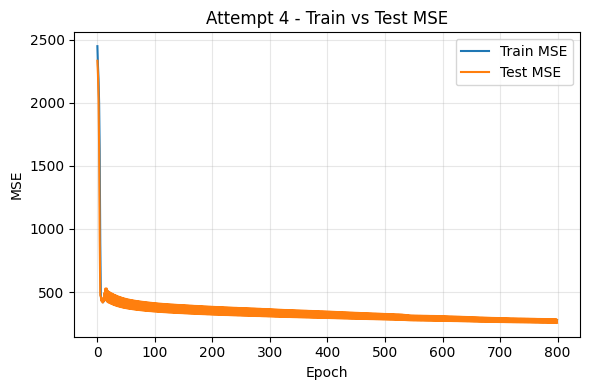

In [ ]:
# Plot training vs test loss (Attempt 4)

plt.figure(figsize=(6,4))

plt.plot(train_mse_history_4, label="Train MSE")
plt.plot(test_mse_history_4, label="Test MSE")

plt.title("Attempt 4 - Train vs Test MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

final_test_mse_4 = test_mse_history_4[-1]
best_test_mse_4  = min(test_mse_history_4)

final_test_r2_4  = test_r2_history_4[-1]
best_test_r2_4   = max(test_r2_history_4)


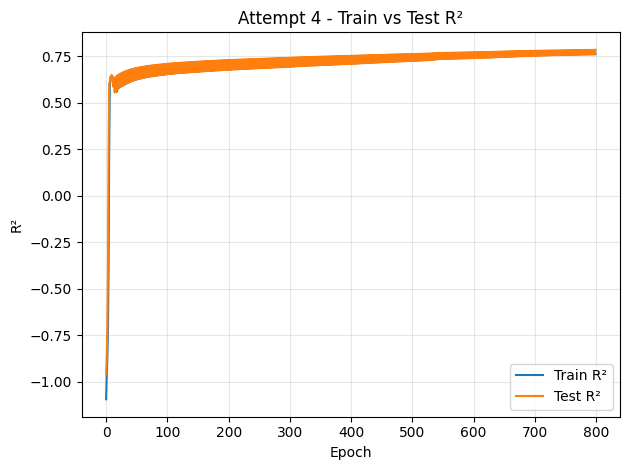

In [ ]:
# Plot R² learning curve for Attempt 4

plt.figure()

plt.plot(train_r2_history_4, label="Train R²")
plt.plot(test_r2_history_4, label="Test R²")

plt.title("Attempt 4 - Train vs Test R²")
plt.xlabel("Epoch")
plt.ylabel("R²")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**### Attempt 4 -- Results Interpretation**

Observations:
- Training remained stable
- Test MSE increased compared to Attempt 3
- Test R² decreased slightly. Similar convergence level to Attempt 3 suggests increased depth did not improve learning.

Conclusion:

Increasing network depth did not improve performance. This suggests that additional complexity introduced unnecessary parameters without improving generalisation, indicating that the previous architecture was already sufficient for this dataset.

In [ ]:
# Final Comparison Across Attempts

import pandas as pd

comparison_data = {
    "Attempt": ["Attempt 1", "Attempt 2", "Attempt 3", "Attempt 4"],
    "Architecture": ["81→8→1", "81→8→1", "81→16→1", "81→16→8→1"],
    "Learning Rate": [0.01, 0.001, 0.001, 0.001],
    "Test MSE": [
    "NaN",
    round(best_test_mse_2, 2),
    round(best_test_mse_3, 2),
    round(best_test_mse_4, 2)
],
    "Test R²": [
    "NaN",
    round(best_test_r2_2, 3),
    round(best_test_r2_3, 3),
    round(best_test_r2_4, 3)
],
    "Interpretation": [
        "Diverged (LR too high)",
        "Stable training",
        "Best performance",
        "More complex but worse"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
(
    comparison_df.style
    .hide(axis="index")
    .set_properties(subset=["Attempt"], **{"font-weight": "bold"})
)

Attempt,Architecture,Learning Rate,Test MSE,Test R²,Interpretation
Attempt 1,81→8→1,0.010000,NaN,NaN,Diverged (LR too high)
Attempt 2,81→8→1,0.001000,244.730000,0.795000,Stable training
Attempt 3,81→16→1,0.001000,242.470000,0.796000,Best performance
Attempt 4,81→16→8→1,0.001000,256.380000,0.785000,More complex but worse


**## Final Discussion and Model Selection**

Across the experiments, each attempt modified a single variable to understand its effect on training stability and generalisation.

- High learning rate caused instability and divergence (Attempt 1).
- Reducing the learning rate stabilised optimisation and enabled convergence (Attempt 2).
- Increasing model capacity improved performance slightly (Attempt 3).
- Adding extra depth increased complexity without improving generalisation (Attempt 4).

These results suggest that this dataset benefits more from moderate model capacity than deeper architectures.

**### Best Model Selected**

**Attempt 3 (81 → 16 → 1, learning rate = 0.001)**

This model achieved the best balance between training stability and test performance.